# KLE under CoT — Multi-dataset analysis (supervisor meeting)

Unified analysis of all available results. **N=1000, seed=42, LLM-as-Judge labels.**

| Dataset | Llama-3.1-8B | Mistral-7B |
|---|---|---|
| TriviaQA | BB+WB, C1–C4 | — |
| NQ-Open | BB+WB, C1–C4 | — |
| MoreHopQA | BB+WB, C1–C4 | BB+WB, C1–C4 |

External baselines (post-hoc from C2 logs): **SelfCheckGPT-NLI** (black-box),
**LLM-Check** (white-box, 5 detectors).

Notes:
- White-box C4 = *hidden-state kernel-VNE variant of KLE* (own contribution; not in the official repo).
- Black-box C4 has **no** attention aggregation (RQ2 leakage guard) → only `max`/`mean`.
- C4 `max_steps`: TriviaQA/NQ-Open = 3, MoreHopQA = 5.
- Run this notebook from the `results/` directory; all figures are saved as PNG and
  tables as CSV under `results/figures/`.
- Bootstrap CI cells take ~1–2 min on first run (results are cached).


In [44]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score, roc_curve

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

DATA_DIR = "."            # run from the results/ directory
FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)

N_BOOT, RNG_SEED = 2000, 0

# Fixed condition colors (same in every figure; palette passed the CVD validator)
COL = {"C1": "#2a78d6", "C2": "#1baf7a", "C3": "#eda100", "C4": "#4a3aa7",
       "SelfCheckGPT": "#e87ba4", "LLM-Check": "#eb6834",
       "SemanticEntropy": "#008300",
       "correct": "#9a9992", "halluc": "#e34948"}

DATASETS = ["triviaqa", "nqopen", "morehopqa"]
DS_LABEL = {"triviaqa": "TriviaQA", "nqopen": "NQ-Open", "morehopqa": "MoreHopQA"}
CONDS = ["C1", "C2", "C3", "C4:max", "C4:mean", "C4:attn_mean"]

# (dataset, model, box) -> {cond: file path}
REG = {}
REG[("triviaqa", "8b", "bb")] = {
    "C1": "black-box/triviaqa/c1_triviaqa_llama_bb.json",
    "C2": "black-box/triviaqa/c2_triviaqa_llama_bb.json",
    "C3": "black-box/triviaqa/c3_triviaiqa_llama_bb.json",  # typo in file name
    "C4": "black-box/triviaqa/c4_triviaqa_llama_bb.json"}
REG[("triviaqa", "8b", "wb")] = {
    f"C{i}": f"white-box/triviaqa/c{i}_triviaqa_llama_wb.json" for i in range(1, 5)}
for ds in ["nqopen", "morehopqa"]:
    for model in (["8b"] if ds == "nqopen" else ["8b", "mistral"]):
        REG[(ds, model, "bb")] = {
            f"C{i}": f"black-box/{ds}/c{i}_{ds}_{model}_BB_results.json" for i in range(1, 5)}
        REG[(ds, model, "wb")] = {
            f"C{i}": f"white-box/{ds}/c{i}_{ds}_{model}_WB_results.json" for i in range(1, 5)}

def load_json(rel):
    with open(os.path.join(DATA_DIR, rel)) as f:
        return json.load(f)

print("Registered pipeline groups:", len(REG))

Registered pipeline groups: 8


## 1. Helpers — score extraction, bootstrap CI, AUARC

- **Score direction:** everywhere *higher score = more uncertain = hallucination expected*.
  LLM-Check detectors are kept in their stored direction (verified against reported AUROC).
- **CI:** nonparametric bootstrap (resampling at the question level, B=2000), 95% percentile.
- **Paired Δ:** two runs are matched on question ids; ΔAUROC is computed per resample
  → CI + two-sided p.
- **AUARC:** most-uncertain examples are rejected first; mean accuracy of the retained
  set over all coverage levels. References: `random` = accuracy without rejection
  (base acc), `oracle` = perfect ranking by the true label.

In [45]:
def get_id(r):
    return r.get("id", r.get("qid"))

def extract_std(d, score_key):
    """C1-C3: score_key='kle_full' (BB) / 'vne' (WB); label=judge_correct."""
    det = d["details"]
    return {"ids": np.array([get_id(r) for r in det]),
            "s":   np.array([r[score_key] for r in det], float),
            "y":   np.array([0 if r["judge_correct"] else 1 for r in det], int)}

def extract_c4(d, agg):
    det = [r for r in d["details"] if r.get("error") is None and r.get("agg")]
    return {"ids": np.array([get_id(r) for r in det]),
            "s":   np.array([r["agg"][agg] for r in det], float),
            "y":   np.array([int(r["is_halluc"]) for r in det], int)}

def fast_auroc(y, s):
    """Rank-based AUROC (= roc_auc_score; average ranks on ties)."""
    r = rankdata(s)
    n1 = int(y.sum()); n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def bootstrap_auroc(y, s, n_boot=N_BOOT, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n = len(y); out = np.full(n_boot, np.nan)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yb = y[idx]
        if 0 < yb.sum() < n:
            out[b] = fast_auroc(yb, s[idx])
    return np.nanpercentile(out, [2.5, 97.5])

def paired_delta(runA, runB, n_boot=N_BOOT, seed=RNG_SEED):
    """AUROC(A) - AUROC(B); paired bootstrap over the shared question set."""
    ia = {q: i for i, q in enumerate(runA["ids"])}
    ib = {q: i for i, q in enumerate(runB["ids"])}
    common = [q for q in runA["ids"] if q in ib]
    ya = runA["y"][[ia[q] for q in common]]; sa = runA["s"][[ia[q] for q in common]]
    yb = runB["y"][[ib[q] for q in common]]; sb = runB["s"][[ib[q] for q in common]]
    n = len(common); rng = np.random.default_rng(seed)
    d0 = fast_auroc(ya, sa) - fast_auroc(yb, sb)
    deltas = []
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        y1, y2 = ya[idx], yb[idx]
        if 0 < y1.sum() < n and 0 < y2.sum() < n:
            deltas.append(fast_auroc(y1, sa[idx]) - fast_auroc(y2, sb[idx]))
    deltas = np.array(deltas)
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    p = min(1.0, 2 * min((deltas <= 0).mean(), (deltas >= 0).mean()))
    return d0, lo, hi, p, n

def auarc(y, s, seed=RNG_SEED):
    """Area under the accuracy-rejection curve; ties broken at random."""
    rng = np.random.default_rng(seed)
    n = len(y)
    order = np.lexsort((rng.random(n), s))       # ascending s = most confident first
    correct = (1 - y)[order]
    accs = np.cumsum(correct) / np.arange(1, n + 1)
    return accs.mean()

def auarc_oracle(y):
    correct = np.sort(1 - y)[::-1]
    return (np.cumsum(correct) / np.arange(1, len(y) + 1)).mean()

print("ok")

ok


## 2. Loading + verification (reported vs recomputed AUROC)

Each file's stored AUROC is compared against the value recomputed from `details`.
`max |diff|` should be ≈ 0; otherwise the score direction / label mapping is wrong.

In [46]:
RUNS, HALLUC = {}, {}
for (ds, model, box), files in REG.items():
    for cond, rel in files.items():
        d = load_json(rel)
        HALLUC[(ds, model, box, cond)] = d["hallucination_rate"]
        if cond == "C4":
            for agg, rep in d["auroc"].items():
                run = extract_c4(d, agg); run["reported"] = rep
                RUNS[(ds, model, box, f"C4:{agg}")] = run
        else:
            run = extract_std(d, "kle_full" if box == "bb" else "vne")
            run["reported"] = d["auroc"]
            RUNS[(ds, model, box, cond)] = run

BRUNS = {}
for ds in DATASETS:
    d = load_json(f"selfcheck_c2_{ds}_8b_results.json")
    det = [r for r in d["details"] if r.get("error") is None]
    BRUNS[(ds, "8b", "SelfCheckGPT")] = {
        "ids": np.array([r["id"] for r in det]),
        "s":   np.array([r["score"] for r in det], float),
        "y":   np.array([int(r["is_halluc"]) for r in det], int),
        "reported": d["auroc"]}
for ds, model in [("triviaqa", "8b"), ("nqopen", "8b"),
                  ("morehopqa", "8b"), ("morehopqa", "mistral")]:
    d = load_json(f"llm-check/llmcheck_c2_{ds}_{model}_results.json")
    det = [r for r in d["details"] if r.get("error") is None]
    for name, rep in d["auroc"].items():
        BRUNS[(ds, model, f"LLM-Check:{name}")] = {
            "ids": np.array([r["id"] for r in det]),
            "s":   np.array([r["scores"][name] for r in det], float),
            "y":   np.array([int(r["is_halluc"]) for r in det], int),
            "reported": rep}

ALL = {**RUNS, **BRUNS}
print(f"KLE runs: {len(RUNS)}  |  baseline runs: {len(BRUNS)}")

KLE runs: 44  |  baseline runs: 23


In [47]:
rows = []
for key, r in ALL.items():
    a = roc_auc_score(r["y"], r["s"])
    rows.append(dict(run="/".join(map(str, key)), n=len(r["y"]),
                     reported=r["reported"], recomputed=a, diff=abs(a - r["reported"])))
ver = pd.DataFrame(rows).sort_values("diff", ascending=False)
print("max |reported - recomputed| =", round(ver["diff"].max(), 6))
ver.head(8).round(4)

max |reported - recomputed| = 0.0


,run,n,reported,recomputed,diff
0,triviaqa/8b/bb/C1,1000,0.8432,0.8432,0.0
50,triviaqa/8b/LLM-Check:logit_entropy,1000,0.7135,0.7135,0.0
36,morehopqa/mistral/bb/C4:max,1000,0.5775,0.5775,0.0
37,morehopqa/mistral/bb/C4:mean,1000,0.6127,0.6127,0.0
38,morehopqa/mistral/wb/C1,1000,0.6557,0.6557,0.0
39,morehopqa/mistral/wb/C2,1000,0.5131,0.5131,0.0
40,morehopqa/mistral/wb/C3,1000,0.5499,0.5499,0.0
41,morehopqa/mistral/wb/C4:max,1000,0.6094,0.6094,0.0


In [48]:
# AUROC + 95% CI cache (first call is slow, later calls are instant)
CI = {}
def auroc_ci(key):
    if key not in CI:
        r = ALL[key]
        lo, hi = bootstrap_auroc(r["y"], r["s"])
        CI[key] = (fast_auroc(r["y"], r["s"]), lo, hi)
    return CI[key]

def fmt_ci(key):
    if key not in ALL:
        return "-"
    a, lo, hi = auroc_ci(key)
    return f"{a:.3f} [{lo:.3f}, {hi:.3f}]"

print("ok")

ok


## 3. T1 — Master AUROC table (Llama-3.1-8B), 95% bootstrap CI

C4 rows are aggregation variants; `attn_mean` is absent in BB by design.

In [49]:
cols = {}
for ds in DATASETS:
    for box in ["bb", "wb"]:
        cols[(DS_LABEL[ds], box.upper())] = {
            c: fmt_ci((ds, "8b", box, c)) for c in CONDS if (ds, "8b", box, c) in RUNS}
t1 = pd.DataFrame(cols).reindex(CONDS).fillna("-")
t1.to_csv(f"{FIG_DIR}/t1_master_auroc_8b.csv")
t1

TriviaQA                        \
                                BB                    WB   
C1            0.843 [0.813, 0.870]  0.782 [0.749, 0.813]   
C2            0.709 [0.665, 0.755]  0.692 [0.651, 0.731]   
C3            0.864 [0.838, 0.889]  0.821 [0.792, 0.847]   
C4:max        0.677 [0.636, 0.716]  0.785 [0.752, 0.817]   
C4:mean       0.629 [0.588, 0.666]  0.773 [0.739, 0.804]   
C4:attn_mean                     -  0.785 [0.753, 0.816]   

                           NQ-Open                        \
                                BB                    WB   
C1            0.728 [0.696, 0.758]  0.740 [0.704, 0.773]   
C2            0.645 [0.607, 0.683]  0.672 [0.636, 0.706]   
C3            0.742 [0.711, 0.773]  0.743 [0.710, 0.773]   
C4:max        0.642 [0.606, 0.676]  0.707 [0.675, 0.740]   
C4:mean       0.634 [0.599, 0.669]  0.707 [0.675, 0.739]   
C4:attn_mean                     -  0.724 [0.693, 0.756]   

                         MoreHopQA                        
                                BB                    WB  
C1            0.366 [0.320, 0.408]  0.465 [0.417, 0.514]  
C2            0.546 [0.505, 0.587]  0.644 [0.602, 0.686]  
C3            0.681 [0.641, 0.722]  0.639 [0.594, 0.682]  
C4:max        0.590 [0.538, 0.644]  0.649 [0.600, 0.697]  
C4:mean       0.713 [0.668, 0.755]  0.681 [0.634, 0.726]  
C4:attn_mean                     -  0.664 [0.615, 0.710]

## 4. T2 — Model comparison (MoreHopQA): Llama-3.1-8B vs Mistral-7B

In [50]:
cols = {}
for model in ["8b", "mistral"]:
    for box in ["bb", "wb"]:
        cols[(model, box.upper())] = {
            c: fmt_ci(("morehopqa", model, box, c))
            for c in CONDS if ("morehopqa", model, box, c) in RUNS}
t2 = pd.DataFrame(cols).reindex(CONDS).fillna("-")
t2.to_csv(f"{FIG_DIR}/t2_morehopqa_models.csv")
t2

8b                        \
                                BB                    WB   
C1            0.366 [0.320, 0.408]  0.465 [0.417, 0.514]   
C2            0.546 [0.505, 0.587]  0.644 [0.602, 0.686]   
C3            0.681 [0.641, 0.722]  0.639 [0.594, 0.682]   
C4:max        0.590 [0.538, 0.644]  0.649 [0.600, 0.697]   
C4:mean       0.713 [0.668, 0.755]  0.681 [0.634, 0.726]   
C4:attn_mean                     -  0.664 [0.615, 0.710]   

                           mistral                        
                                BB                    WB  
C1            0.464 [0.411, 0.517]  0.656 [0.607, 0.703]  
C2            0.548 [0.509, 0.584]  0.513 [0.474, 0.550]  
C3            0.684 [0.631, 0.731]  0.550 [0.496, 0.603]  
C4:max        0.578 [0.524, 0.628]  0.609 [0.554, 0.664]  
C4:mean       0.613 [0.560, 0.664]  0.610 [0.558, 0.662]  
C4:attn_mean                     -  0.610 [0.554, 0.664]

## 5. T3 — External baselines vs our conditions (Llama-3.1-8B)

SelfCheckGPT-NLI is black-box; LLM-Check detectors are **white-box**
(logits/hidden/attn) — box type in parentheses per row. All baselines operate on
C2 (holistic CoT) outputs; the KLE rows use their own condition's outputs.

In [51]:
rows = {}
rows["KLE C1 (BB)"]      = {DS_LABEL[ds]: fmt_ci((ds, "8b", "bb", "C1")) for ds in DATASETS}
rows["KLE C3 (BB)"]      = {DS_LABEL[ds]: fmt_ci((ds, "8b", "bb", "C3")) for ds in DATASETS}
rows["KLE C4:mean (BB)"] = {DS_LABEL[ds]: fmt_ci((ds, "8b", "bb", "C4:mean")) for ds in DATASETS}
rows["SelfCheckGPT-NLI (BB)"] = {DS_LABEL[ds]: fmt_ci((ds, "8b", "SelfCheckGPT")) for ds in DATASETS}
for det in ["hidden", "attn", "ppl", "logit_entropy", "window_entropy"]:
    rows[f"LLM-Check {det} (WB)"] = {
        DS_LABEL[ds]: fmt_ci((ds, "8b", f"LLM-Check:{det}")) for ds in DATASETS}
t3 = pd.DataFrame(rows).T[[DS_LABEL[d] for d in DATASETS]]
t3.to_csv(f"{FIG_DIR}/t3_baselines_8b.csv")
t3

,TriviaQA,NQ-Open,MoreHopQA
KLE C1 (BB),"0.843 [0.813, 0.870]","0.728 [0.696, 0.758]","0.366 [0.320, 0.408]"
KLE C3 (BB),"0.864 [0.838, 0.889]","0.742 [0.711, 0.773]","0.681 [0.641, 0.722]"
KLE C4:mean (BB),"0.629 [0.588, 0.666]","0.634 [0.599, 0.669]","0.713 [0.668, 0.755]"
SelfCheckGPT-NLI (BB),"0.792 [0.757, 0.826]","0.675 [0.638, 0.711]","0.501 [0.462, 0.540]"
LLM-Check hidden (WB),"0.350 [0.300, 0.400]","0.392 [0.354, 0.431]","0.481 [0.447, 0.518]"
LLM-Check attn (WB),"0.445 [0.398, 0.494]","0.435 [0.397, 0.471]","0.361 [0.326, 0.396]"
LLM-Check ppl (WB),"0.675 [0.627, 0.717]","0.656 [0.619, 0.694]","0.683 [0.647, 0.716]"
LLM-Check logit_entropy (WB),"0.714 [0.666, 0.755]","0.669 [0.633, 0.707]","0.709 [0.674, 0.743]"
LLM-Check window_entropy (WB),"0.699 [0.654, 0.740]","0.654 [0.618, 0.690]","0.593 [0.552, 0.633]"


## 6. T4 — Hallucination rate (dataset × model × box × condition)

Task difficulty + base-rate differences across conditions (CoT improves accuracy
in C2 → lower positive rate). AUROC is relatively robust to the base rate, but we
report it for transparency.

In [52]:
rows = [dict(dataset=DS_LABEL[ds], model=model, box=box.upper(), cond=cond, rate=hr)
        for (ds, model, box, cond), hr in HALLUC.items()]
t4 = (pd.DataFrame(rows)
        .pivot_table(index="cond", columns=["dataset", "model", "box"], values="rate")
        .round(3))
t4 = t4[[c for lbl in [DS_LABEL[d] for d in DATASETS] for c in t4.columns if c[0] == lbl]]
t4.to_csv(f"{FIG_DIR}/t4_halluc_rates.csv")
t4

dataset TriviaQA        NQ-Open        MoreHopQA                      
model         8b             8b               8b        mistral       
box           BB     WB      BB     WB        BB     WB      BB     WB
cond                                                                  
C1         0.244  0.243   0.333  0.326     0.820  0.821   0.886  0.871
C2         0.190  0.189   0.305  0.305     0.714  0.731   0.634  0.627
C3         0.239  0.246   0.387  0.403     0.813  0.808   0.882  0.870
C4         0.265  0.265   0.439  0.439     0.846  0.846   0.876  0.876

## 7. G1 (headline) — AUROC by condition × dataset, Llama-3.1-8B

The main story at a glance: C3 leads on single-hop; on multi-hop (MoreHopQA)
**C1 collapses (below chance)** and **C4 (stepwise) becomes the best black-box
detector**. C4 representative: BB → `mean`, WB → `attn_mean`.

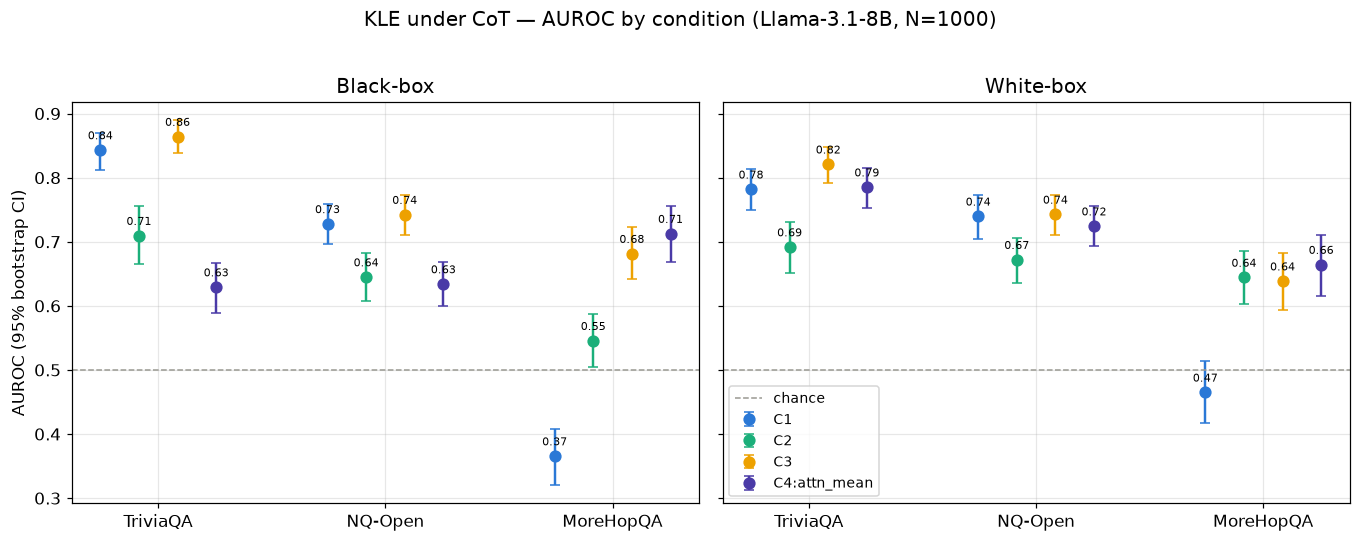

In [53]:
REP = {"bb": ["C1", "C2", "C3", "C4:mean"], "wb": ["C1", "C2", "C3", "C4:attn_mean"]}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, box in zip(axes, ["bb", "wb"]):
    for j, cond in enumerate(REP[box]):
        xs, ys, lo_e, hi_e = [], [], [], []
        for i, ds in enumerate(DATASETS):
            a, lo, hi = auroc_ci((ds, "8b", box, cond))
            xs.append(i + (j - 1.5) * 0.17)
            ys.append(a); lo_e.append(a - lo); hi_e.append(hi - a)
        ax.errorbar(xs, ys, yerr=[lo_e, hi_e], fmt="o", ms=7, capsize=3, lw=1.6,
                    color=COL[cond.split(":")[0]], label=cond)
        for x, v in zip(xs, ys):
            ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                        xytext=(0, 7), ha="center", fontsize=7.5)
    ax.axhline(0.5, color="#9a9992", ls="--", lw=1, label="chance")
    ax.set_xticks(range(len(DATASETS)))
    ax.set_xticklabels([DS_LABEL[d] for d in DATASETS])
    ax.set_title("Black-box" if box == "bb" else "White-box")
axes[0].set_ylabel("AUROC (95% bootstrap CI)")
axes[1].legend(loc="lower left", fontsize=9)
fig.suptitle("KLE under CoT — AUROC by condition (Llama-3.1-8B, N=1000)", y=1.02)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g1_headline_auroc.png", bbox_inches="tight")
plt.show()

## 8. G2 — ROC curves (black-box, Llama-3.1-8B), one panel per dataset

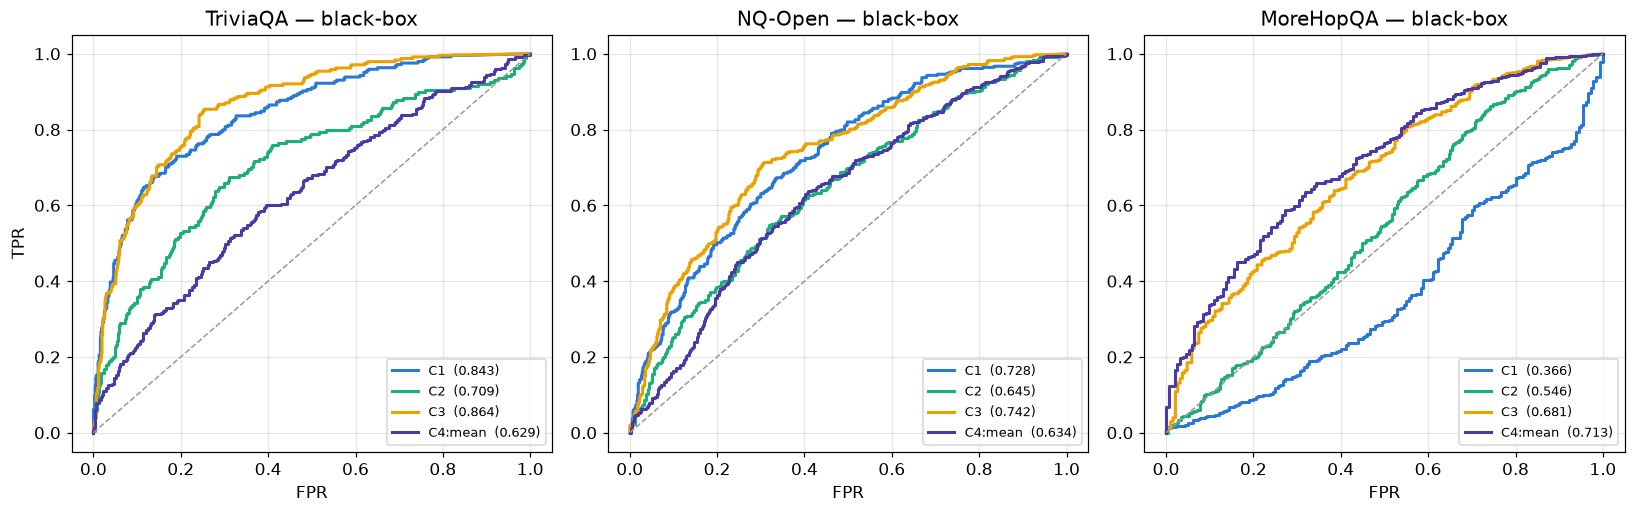

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, ds in zip(axes, DATASETS):
    for cond in ["C1", "C2", "C3", "C4:mean"]:
        r = RUNS[(ds, "8b", "bb", cond)]
        fpr, tpr, _ = roc_curve(r["y"], r["s"])
        ax.plot(fpr, tpr, lw=2, color=COL[cond.split(":")[0]],
                label=f"{cond}  ({fast_auroc(r['y'], r['s']):.3f})")
    ax.plot([0, 1], [0, 1], ls="--", color="#9a9992", lw=1)
    ax.set_title(f"{DS_LABEL[ds]} — black-box")
    ax.set_xlabel("FPR"); ax.legend(fontsize=8.5, loc="lower right")
axes[0].set_ylabel("TPR")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g2_roc_bb.png", bbox_inches="tight")
plt.show()

## 9. G3 — External baseline comparison (Llama-3.1-8B)

Circle = black-box, square = white-box (LLM-Check). LLM-Check representative:
its best detector, `logit_entropy`.

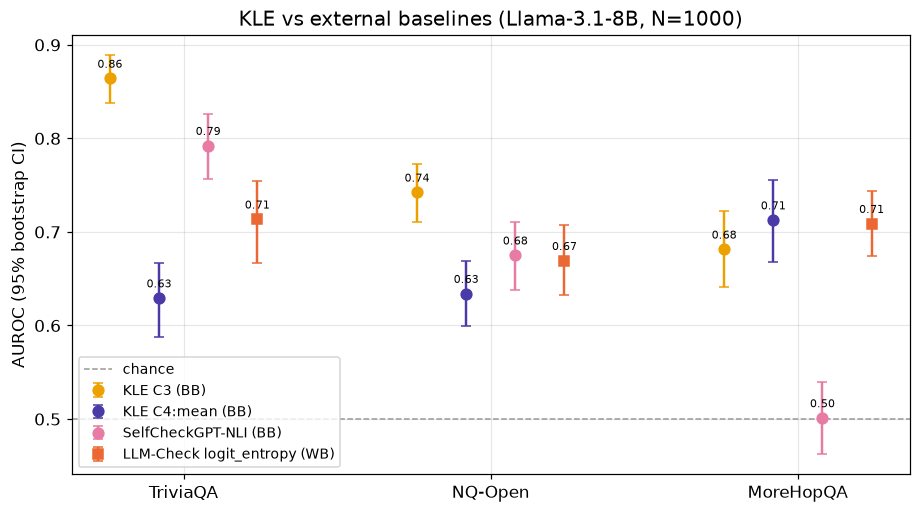

In [55]:
methods = [
    ("KLE C3 (BB)",                 lambda ds: (ds, "8b", "bb", "C3"),            COL["C3"], "o"),
    ("KLE C4:mean (BB)",            lambda ds: (ds, "8b", "bb", "C4:mean"),       COL["C4"], "o"),
    ("SelfCheckGPT-NLI (BB)",       lambda ds: (ds, "8b", "SelfCheckGPT"),        COL["SelfCheckGPT"], "o"),
    ("LLM-Check logit_entropy (WB)", lambda ds: (ds, "8b", "LLM-Check:logit_entropy"), COL["LLM-Check"], "s"),
]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for j, (name, keyf, col, mk) in enumerate(methods):
    xs, ys, lo_e, hi_e = [], [], [], []
    for i, ds in enumerate(DATASETS):
        a, lo, hi = auroc_ci(keyf(ds))
        xs.append(i + (j - 1.5) * 0.16)
        ys.append(a); lo_e.append(a - lo); hi_e.append(hi - a)
    ax.errorbar(xs, ys, yerr=[lo_e, hi_e], fmt=mk, ms=7, capsize=3, lw=1.6,
                color=col, label=name)
    for x, v in zip(xs, ys):
        ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=7.5)
ax.axhline(0.5, color="#9a9992", ls="--", lw=1, label="chance")
ax.set_xticks(range(len(DATASETS)))
ax.set_xticklabels([DS_LABEL[d] for d in DATASETS])
ax.set_ylabel("AUROC (95% bootstrap CI)")
ax.set_title("KLE vs external baselines (Llama-3.1-8B, N=1000)")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g3_baselines.png", bbox_inches="tight")
plt.show()

## 10. G4 — C4 aggregation variants (Llama-3.1-8B)

Marker = variant (same color; shape disambiguates): ●=`max`, ■=`mean`, ▲=`attn_mean`.
The BB panel has no `attn_mean` (RQ2 leakage guard). The BB vs WB gap is the direct
visual for RQ2's "how much does the black-box variant capture" question.

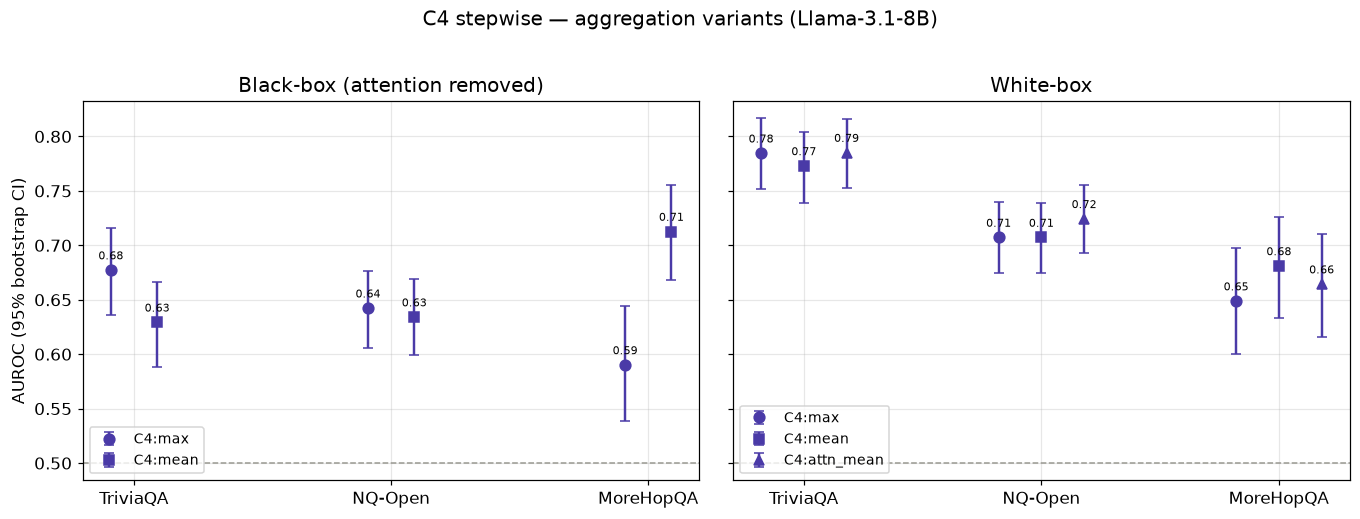

In [56]:
MARK = {"max": "o", "mean": "s", "attn_mean": "^"}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
for ax, box in zip(axes, ["bb", "wb"]):
    aggs = ["max", "mean"] + (["attn_mean"] if box == "wb" else [])
    for j, agg in enumerate(aggs):
        xs, ys, lo_e, hi_e = [], [], [], []
        for i, ds in enumerate(DATASETS):
            key = (ds, "8b", box, f"C4:{agg}")
            a, lo, hi = auroc_ci(key)
            xs.append(i + (j - (len(aggs) - 1) / 2) * 0.18)
            ys.append(a); lo_e.append(a - lo); hi_e.append(hi - a)
        ax.errorbar(xs, ys, yerr=[lo_e, hi_e], fmt=MARK[agg], ms=7, capsize=3,
                    lw=1.6, color=COL["C4"], label=f"C4:{agg}")
        for x, v in zip(xs, ys):
            ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                        xytext=(0, 7), ha="center", fontsize=7.5)
    ax.axhline(0.5, color="#9a9992", ls="--", lw=1)
    ax.set_xticks(range(len(DATASETS)))
    ax.set_xticklabels([DS_LABEL[d] for d in DATASETS])
    ax.set_title("Black-box (attention removed)" if box == "bb" else "White-box")
    ax.legend(loc="lower left", fontsize=9)
axes[0].set_ylabel("AUROC (95% bootstrap CI)")
fig.suptitle("C4 stepwise — aggregation variants (Llama-3.1-8B)", y=1.02)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g4_c4_aggregations.png", bbox_inches="tight")
plt.show()

## 11. G5 — Score distributions: best separation vs inverted signal

Left: TriviaQA C3 (BB) — correct/hallucination separate cleanly.
Right: MoreHopQA C1 (BB) — the distributions overlap in reverse
(the visual behind AUROC < 0.5).

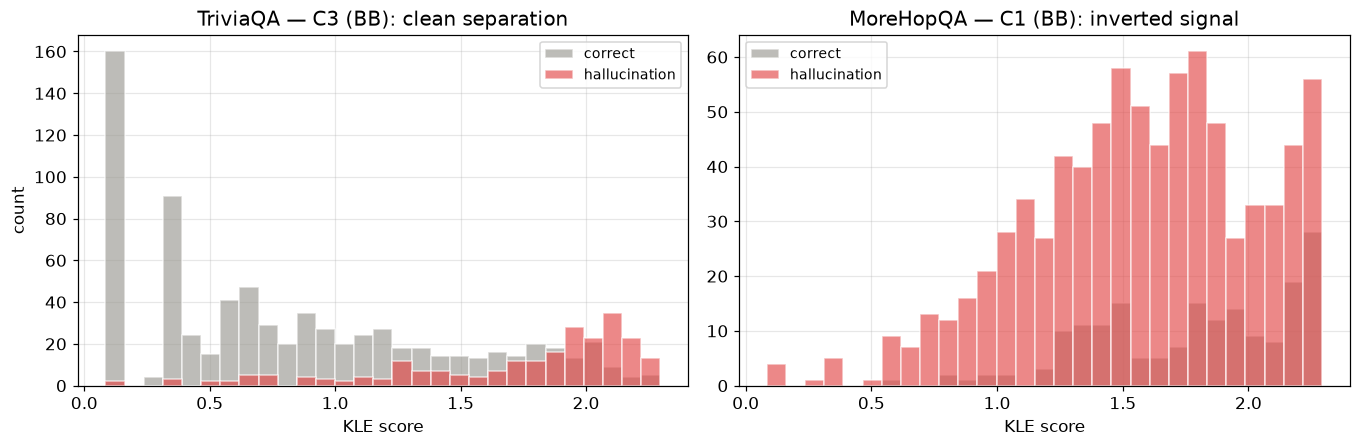

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
panels = [("triviaqa", "C3", "TriviaQA — C3 (BB): clean separation"),
          ("morehopqa", "C1", "MoreHopQA — C1 (BB): inverted signal")]
for ax, (ds, cond, ttl) in zip(axes, panels):
    r = RUNS[(ds, "8b", "bb", cond)]
    bins = np.linspace(r["s"].min(), r["s"].max(), 30)
    ax.hist(r["s"][r["y"] == 0], bins=bins, alpha=0.65, color=COL["correct"],
            edgecolor="white", label="correct")
    ax.hist(r["s"][r["y"] == 1], bins=bins, alpha=0.65, color=COL["halluc"],
            edgecolor="white", label="hallucination")
    ax.set_title(ttl); ax.set_xlabel("KLE score"); ax.legend(fontsize=9)
axes[0].set_ylabel("count")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g5_score_dists.png", bbox_inches="tight")
plt.show()

## 12. Diagnostic — why is C1-MoreHopQA below chance? ("confidently wrong")

Hypothesis: when the model answers a multi-hop question *directly*, it produces
wrong but **semantically consistent** answers → few clusters → low KLE → the
signal inverts. Left panel TriviaQA (expected pattern: hallucination → more
clusters), right panel MoreHopQA (the pattern breaks). Proportions are normalized
within each group.

  TriviaQA: mean clusters correct=4.50  halluc=7.74  | single-cluster correct=14.6%  halluc=0.4%
 MoreHopQA: mean clusters correct=7.61  halluc=6.74  | single-cluster correct=0.0%  halluc=0.5%


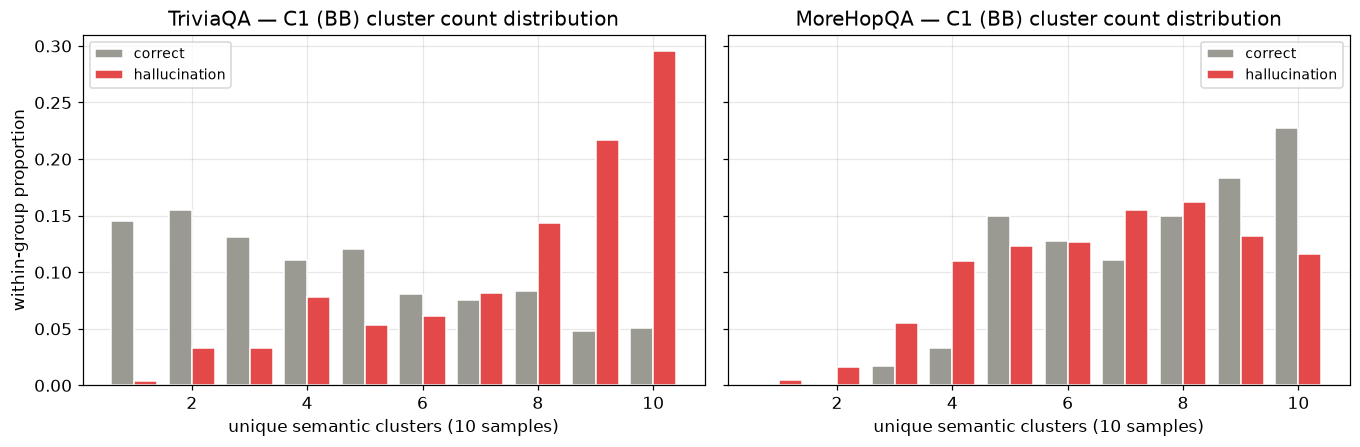

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for ax, ds in zip(axes, ["triviaqa", "morehopqa"]):
    d = load_json(REG[(ds, "8b", "bb")]["C1"])
    cl = np.array([len(set(r["semantic_ids"])) for r in d["details"]])
    y = np.array([0 if r["judge_correct"] else 1 for r in d["details"]])
    vals = np.arange(1, cl.max() + 1)
    w = 0.4
    ax.bar(vals - w / 2, [(cl[y == 0] == v).mean() for v in vals], width=w,
           color=COL["correct"], edgecolor="white", label="correct")
    ax.bar(vals + w / 2, [(cl[y == 1] == v).mean() for v in vals], width=w,
           color=COL["halluc"], edgecolor="white", label="hallucination")
    ax.set_title(f"{DS_LABEL[ds]} — C1 (BB) cluster count distribution")
    ax.set_xlabel("unique semantic clusters (10 samples)")
    ax.legend(fontsize=9)
    print(f"{DS_LABEL[ds]:>10}: mean clusters correct={cl[y==0].mean():.2f}  "
          f"halluc={cl[y==1].mean():.2f}  | single-cluster correct="
          f"{(cl[y==0]==1).mean():.1%}  halluc={(cl[y==1]==1).mean():.1%}")
axes[0].set_ylabel("within-group proportion")
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g6_c1_morehopqa_diagnostic.png", bbox_inches="tight")
plt.show()

## 13. Paired bootstrap — key ΔAUROC comparisons

Paired bootstrap over the shared question set (B=2000). Note: each condition's
labels come from its own generation; pairing is at the *question* level. `p` is a
two-sided bootstrap p-value. The last two rows are cross-method (vs baselines).

In [59]:
PAIRS = [
    ("TriviaQA BB:  C3 - C1",              ("triviaqa", "8b", "bb", "C3"),  ("triviaqa", "8b", "bb", "C1")),
    ("NQ-Open BB:   C3 - C1",              ("nqopen", "8b", "bb", "C3"),    ("nqopen", "8b", "bb", "C1")),
    ("TriviaQA BB:  C3 - C4:max",          ("triviaqa", "8b", "bb", "C3"),  ("triviaqa", "8b", "bb", "C4:max")),
    ("MoreHopQA BB: C4:mean - C1",         ("morehopqa", "8b", "bb", "C4:mean"), ("morehopqa", "8b", "bb", "C1")),
    ("MoreHopQA BB: C4:mean - C3",         ("morehopqa", "8b", "bb", "C4:mean"), ("morehopqa", "8b", "bb", "C3")),
    ("MoreHopQA BB: C3 - C2",              ("morehopqa", "8b", "bb", "C3"), ("morehopqa", "8b", "bb", "C2")),
    ("MoreHopQA WB: C4:mean - C1",         ("morehopqa", "8b", "wb", "C4:mean"), ("morehopqa", "8b", "wb", "C1")),
    ("TriviaQA BB:  C3 - SelfCheckGPT",    ("triviaqa", "8b", "bb", "C3"),  ("triviaqa", "8b", "SelfCheckGPT")),
    ("MoreHopQA BB: C4:mean - SelfCheckGPT", ("morehopqa", "8b", "bb", "C4:mean"), ("morehopqa", "8b", "SelfCheckGPT")),
    ("MoreHopQA:    C4:mean(BB) - LLMCheck logit_ent(WB)",
     ("morehopqa", "8b", "bb", "C4:mean"), ("morehopqa", "8b", "LLM-Check:logit_entropy")),
]
rows = []
for name, ka, kb in PAIRS:
    d0, lo, hi, p, n = paired_delta(ALL[ka], ALL[kb])
    rows.append(dict(pair=name, delta_auroc=d0, ci_lo=lo, ci_hi=hi, p=p, n_common=n))
t_pairs = pd.DataFrame(rows).round(4)
t_pairs.to_csv(f"{FIG_DIR}/t5_paired_deltas.csv", index=False)
t_pairs

,pair,delta_auroc,ci_lo,ci_hi,p,n_common
0,TriviaQA BB: C3 - C1,0.0209,-0.0126,0.0580,0.205,1000
1,NQ-Open BB: C3 - C1,0.0144,-0.0226,0.0528,0.442,1000
2,TriviaQA BB: C3 - C4:max,0.1868,0.1413,0.2339,0.000,1000
3,MoreHopQA BB: C4:mean - C1,0.3470,0.2851,0.4117,0.000,1000
4,MoreHopQA BB: C4:mean - C3,0.0313,-0.0221,0.0845,0.271,1000
5,MoreHopQA BB: C3 - C2,0.1358,0.0830,0.1920,0.000,1000
6,MoreHopQA WB: C4:mean - C1,0.2160,0.1497,0.2802,0.000,1000
7,TriviaQA BB: C3 - SelfCheckGPT,0.0718,0.0288,0.1154,0.000,1000
8,MoreHopQA BB: C4:mean - SelfCheckGPT,0.2115,0.1531,0.2683,0.000,1000
9,MoreHopQA: C4:mean(BB) - LLMCheck logit_ent...,0.0038,-0.0501,0.0573,0.889,1000


## 14. AUARC — accuracy-rejection (calibration-free)

`auarc` > `base_acc` → the uncertainty score is useful for rejection; `oracle` is
the upper bound. Note: base accuracy differs across conditions (own generations),
so AUARC values are not *raw*-comparable across conditions; read together with
`base_acc`.

In [60]:
rows = []
for ds in DATASETS:
    for box in ["bb", "wb"]:
        for cond in CONDS:
            key = (ds, "8b", box, cond)
            if key not in RUNS:
                continue
            r = RUNS[key]
            rows.append(dict(dataset=DS_LABEL[ds], box=box.upper(), cond=cond,
                             auarc=auarc(r["y"], r["s"]),
                             base_acc=(1 - r["y"]).mean(),
                             oracle=auarc_oracle(r["y"])))
t6 = pd.DataFrame(rows).round(3)
t6_p = t6.pivot_table(index="cond", columns=["dataset", "box"], values="auarc").round(3)
t6_p = t6_p[[c for lbl in [DS_LABEL[d] for d in DATASETS] for c in t6_p.columns if c[0] == lbl]]
t6.to_csv(f"{FIG_DIR}/t6_auarc_long.csv", index=False)
t6_p.to_csv(f"{FIG_DIR}/t6_auarc_8b.csv")
t6_p

dataset      TriviaQA        NQ-Open        MoreHopQA       
box                BB     WB      BB     WB        BB     WB
cond                                                        
C1              0.917  0.893   0.811  0.819     0.118  0.169
C2              0.878  0.895   0.785  0.793     0.347  0.394
C3              0.929  0.908   0.783  0.770     0.296  0.281
C4:attn_mean      NaN  0.880     NaN  0.712       NaN  0.231
C4:max          0.815  0.878   0.666  0.688     0.212  0.226
C4:mean         0.801  0.869   0.665  0.694     0.262  0.247

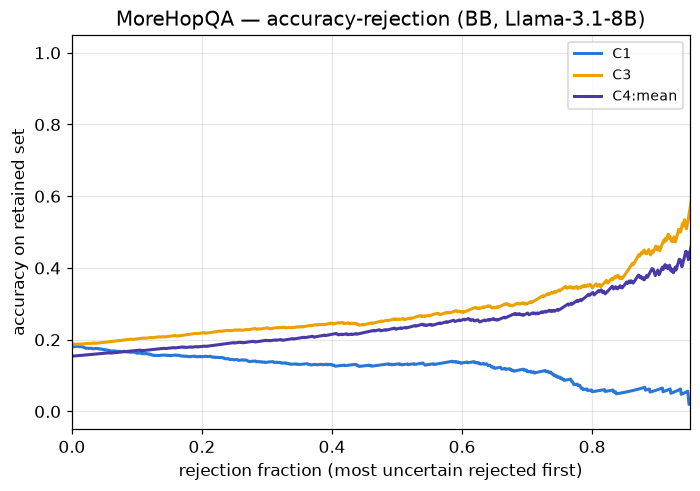

In [61]:
# Rejection curve — MoreHopQA BB (the AUARC counterpart of the headline story)
fig, ax = plt.subplots(figsize=(6.5, 4.6))
for cond in ["C1", "C3", "C4:mean"]:
    r = RUNS[("morehopqa", "8b", "bb", cond)]
    n = len(r["y"])
    order = np.argsort(r["s"])                 # most confident first
    correct = (1 - r["y"])[order]
    ks = np.arange(1, n + 1)
    acc = np.cumsum(correct) / ks
    rej = 1 - ks / n
    ax.plot(rej, acc, lw=2, color=COL[cond.split(":")[0]], label=cond)
ax.set_xlim(0, 0.95)
ax.set_xlabel("rejection fraction (most uncertain rejected first)")
ax.set_ylabel("accuracy on retained set")
ax.set_title("MoreHopQA — accuracy-rejection (BB, Llama-3.1-8B)")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g7_rejection_morehopqa.png", bbox_inches="tight")
plt.show()

## 15. Talking points for the meeting

1. **Main finding (RQ1):** On single-hop, C3 (final-answer span) is the best
   black-box detector (TriviaQA 0.864, NQ-Open 0.742). On multi-hop the picture
   flips: the C1 baseline **drops below chance** (0.366) and C4 stepwise becomes
   the **best black-box detector** (mean 0.713). Step-level uncertainty adds value
   exactly where expected (multi-hop).
2. **The C1-MoreHopQA anomaly is not a bug, it is motivation:** diagnostic in
   section 12 — the model is "confidently wrong" when answering directly;
   consistent-but-wrong answers yield low entropy. This can be presented as
   evidence for why CoT + step-level detection is needed.
3. **Against baselines:** SelfCheckGPT-NLI collapses to 0.50 on MoreHopQA and is
   below C3 even on TriviaQA. LLM-Check's best detector (logit_entropy,
   white-box) is statistically on par with C4:mean (BB) on MoreHopQA — but ours
   is black-box (a point for RQ2).
4. **RQ2:** the C4 BB (no attention) vs WB gap varies by dataset (section 10);
   on MoreHopQA the BB mean even beats the WB mean → the black-box variant is
   defensible.
5. **Transparency notes:** MoreHopQA hallucination rate is 71–89% (hard task;
   judge reliability should be discussed); base rates differ across conditions
   (T4); LLM-Check is white-box; Mistral shows the same pattern on MoreHopQA
   (T2) → the finding is not model-specific.

**Missing / next steps:** Mistral × TriviaQA/NQ-Open, SelfCheckGPT-Mistral,
C4 layer ablation, token-based compute comparison.

## 16. Comparison tables — C2/C4-KLE vs external baselines, per box type

Two tables (Llama-3.1-8B, all three datasets, 95% bootstrap CI; best value per
dataset column in **bold**):

- **T7 (white-box):** C2-KLE (VNE), C4-KLE (`max`/`mean`/`attn_mean`),
  LLM-Check (its best detector, `logit_entropy`; all five detectors are in T3),
  Semantic Entropy.
- **T8 (black-box):** C2-KLE, C4-KLE (`max`/`mean`; `attn_mean` does not exist in
  BB by design), SelfCheckGPT-NLI.

Semantic Entropy is computed post-hoc from the per-cluster log-likelihoods
(`log_lik_per_sem_id`, already sum-normalized) stored in the C2 black-box logs —
the standard Rao-Blackwellized estimator. It requires token likelihoods, so it is
grouped with the white-box methods. All baselines operate on C2 (holistic CoT)
outputs; C4 rows use their own stepwise generations.

**G8** below is the visual companion: one panel per box type, dot + 95% CI,
same layout as G1/G3. C4 variants share the C4 color and are distinguished by
marker shape (●=`max`, ■=`mean`, ▲=`attn_mean`); Semantic Entropy uses ◆.

In [62]:
from scipy.special import logsumexp

def semantic_entropy(log_lik_per_sem_id):
    """Rao-Blackwellized semantic entropy from per-cluster log-likelihoods."""
    ll = np.asarray(log_lik_per_sem_id, float)
    lnp = ll - logsumexp(ll)          # defensive re-normalization
    return float(-np.sum(np.exp(lnp) * lnp))

for ds in DATASETS:
    d = load_json(REG[(ds, "8b", "bb")]["C2"])
    det = d["details"]
    ALL[(ds, "8b", "SemanticEntropy")] = {
        "ids": np.array([get_id(r) for r in det]),
        "s":   np.array([semantic_entropy(r["log_lik_per_sem_id"]) for r in det]),
        "y":   np.array([0 if r["judge_correct"] else 1 for r in det], int),
        "reported": None}

print("Semantic Entropy AUROC:",
      {DS_LABEL[ds]: round(fast_auroc(ALL[(ds, '8b', 'SemanticEntropy')]['y'],
                                      ALL[(ds, '8b', 'SemanticEntropy')]['s']), 3)
       for ds in DATASETS})

Semantic Entropy AUROC: {'TriviaQA': np.float64(0.66), 'NQ-Open': np.float64(0.629), 'MoreHopQA': np.float64(0.57)}


In [63]:
def comparison_table(rows, fname):
    """rows: {label: dataset -> run key}. Bolds the best AUROC per dataset column."""
    disp = pd.DataFrame({DS_LABEL[ds]: {lab: fmt_ci(keyf(ds)) for lab, keyf in rows.items()}
                         for ds in DATASETS})
    num = pd.DataFrame({DS_LABEL[ds]: {lab: (auroc_ci(keyf(ds))[0] if keyf(ds) in ALL else np.nan)
                                       for lab, keyf in rows.items()}
                        for ds in DATASETS})
    disp = disp.reindex(list(rows)); num = num.reindex(list(rows))
    disp.to_csv(f"{FIG_DIR}/{fname}")
    def bold_best(col):
        best = num[col.name].idxmax()
        return ["font-weight: bold" if i == best else "" for i in col.index]
    return disp.style.apply(bold_best, axis=0)

# T7 — white-box comparison
wb_rows = {
    "C2-KLE (WB, VNE)":           lambda ds: (ds, "8b", "wb", "C2"),
    "C4-KLE (WB, max)":           lambda ds: (ds, "8b", "wb", "C4:max"),
    "C4-KLE (WB, mean)":          lambda ds: (ds, "8b", "wb", "C4:mean"),
    "C4-KLE (WB, attn_mean)":     lambda ds: (ds, "8b", "wb", "C4:attn_mean"),
    "LLM-Check (logit_entropy)":  lambda ds: (ds, "8b", "LLM-Check:logit_entropy"),
    "Semantic Entropy":           lambda ds: (ds, "8b", "SemanticEntropy"),
}
comparison_table(wb_rows, "t7_whitebox_comparison.csv")

,TriviaQA,NQ-Open,MoreHopQA
"C2-KLE (WB, VNE)","0.692 [0.651, 0.731]","0.672 [0.636, 0.706]","0.644 [0.602, 0.686]"
"C4-KLE (WB, max)","0.785 [0.752, 0.817]","0.707 [0.675, 0.740]","0.649 [0.600, 0.697]"
"C4-KLE (WB, mean)","0.773 [0.739, 0.804]","0.707 [0.675, 0.739]","0.681 [0.634, 0.726]"
"C4-KLE (WB, attn_mean)","0.785 [0.753, 0.816]","0.724 [0.693, 0.756]","0.664 [0.615, 0.710]"
LLM-Check (logit_entropy),"0.714 [0.666, 0.755]","0.669 [0.633, 0.707]","0.709 [0.674, 0.743]"
Semantic Entropy,"0.660 [0.616, 0.705]","0.629 [0.591, 0.666]","0.570 [0.529, 0.611]"


In [64]:
# T8 — black-box comparison
bb_rows = {
    "C2-KLE (BB)":        lambda ds: (ds, "8b", "bb", "C2"),
    "C4-KLE (BB, max)":   lambda ds: (ds, "8b", "bb", "C4:max"),
    "C4-KLE (BB, mean)":  lambda ds: (ds, "8b", "bb", "C4:mean"),
    "SelfCheckGPT-NLI":   lambda ds: (ds, "8b", "SelfCheckGPT"),
}
comparison_table(bb_rows, "t8_blackbox_comparison.csv")

,TriviaQA,NQ-Open,MoreHopQA
C2-KLE (BB),"0.709 [0.665, 0.755]","0.645 [0.607, 0.683]","0.546 [0.505, 0.587]"
"C4-KLE (BB, max)","0.677 [0.636, 0.716]","0.642 [0.606, 0.676]","0.590 [0.538, 0.644]"
"C4-KLE (BB, mean)","0.629 [0.588, 0.666]","0.634 [0.599, 0.669]","0.713 [0.668, 0.755]"
SelfCheckGPT-NLI,"0.792 [0.757, 0.826]","0.675 [0.638, 0.711]","0.501 [0.462, 0.540]"


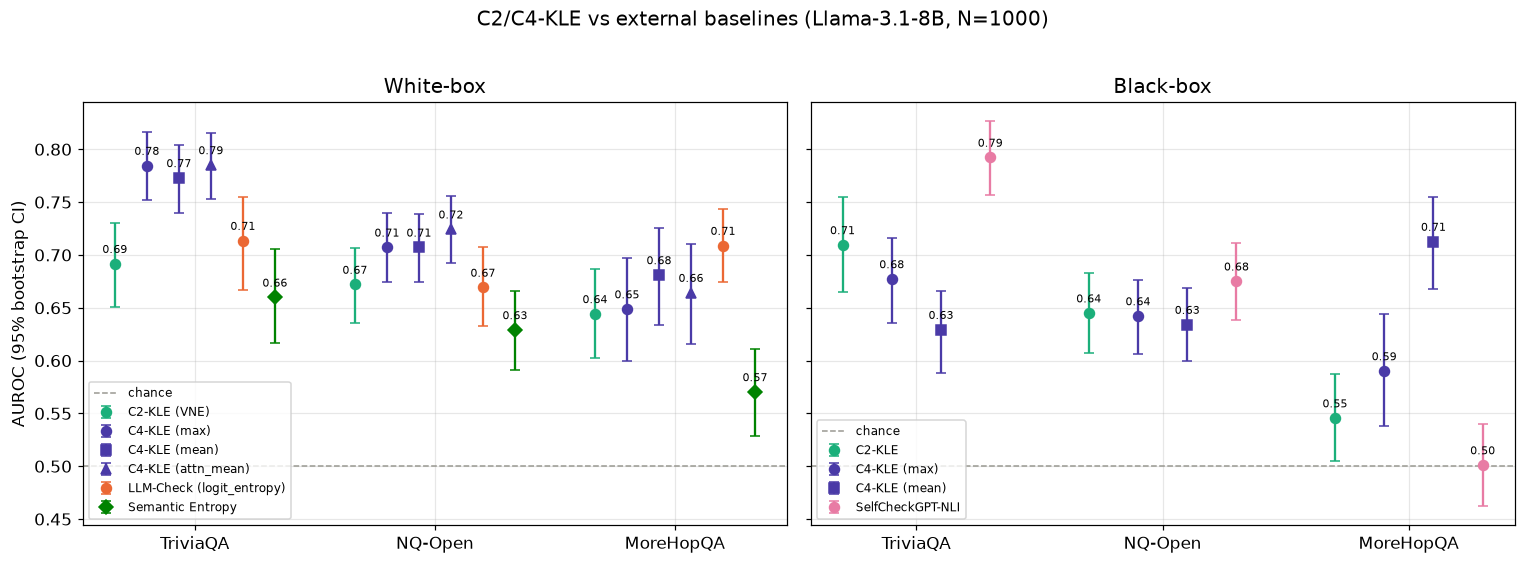

In [65]:
# G8 — visual companion to T7/T8
panels = {
    "White-box": [
        ("C2-KLE (VNE)",              lambda ds: (ds, "8b", "wb", "C2"),           COL["C2"], "o"),
        ("C4-KLE (max)",              lambda ds: (ds, "8b", "wb", "C4:max"),       COL["C4"], "o"),
        ("C4-KLE (mean)",             lambda ds: (ds, "8b", "wb", "C4:mean"),      COL["C4"], "s"),
        ("C4-KLE (attn_mean)",        lambda ds: (ds, "8b", "wb", "C4:attn_mean"), COL["C4"], "^"),
        ("LLM-Check (logit_entropy)", lambda ds: (ds, "8b", "LLM-Check:logit_entropy"), COL["LLM-Check"], "o"),
        ("Semantic Entropy",          lambda ds: (ds, "8b", "SemanticEntropy"),    COL["SemanticEntropy"], "D"),
    ],
    "Black-box": [
        ("C2-KLE",           lambda ds: (ds, "8b", "bb", "C2"),      COL["C2"], "o"),
        ("C4-KLE (max)",     lambda ds: (ds, "8b", "bb", "C4:max"),  COL["C4"], "o"),
        ("C4-KLE (mean)",    lambda ds: (ds, "8b", "bb", "C4:mean"), COL["C4"], "s"),
        ("SelfCheckGPT-NLI", lambda ds: (ds, "8b", "SelfCheckGPT"),  COL["SelfCheckGPT"], "o"),
    ],
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharey=True)
for ax, (ttl, methods) in zip(axes, panels.items()):
    k = len(methods)
    for j, (name, keyf, col, mk) in enumerate(methods):
        xs, ys, lo_e, hi_e = [], [], [], []
        for i, ds in enumerate(DATASETS):
            a, lo, hi = auroc_ci(keyf(ds))
            xs.append(i + (j - (k - 1) / 2) * (0.8 / k))
            ys.append(a); lo_e.append(a - lo); hi_e.append(hi - a)
        ax.errorbar(xs, ys, yerr=[lo_e, hi_e], fmt=mk, ms=6.5, capsize=3, lw=1.5,
                    color=col, label=name)
        for x, v in zip(xs, ys):
            ax.annotate(f"{v:.2f}", (x, v), textcoords="offset points",
                        xytext=(0, 7), ha="center", fontsize=7)
    ax.axhline(0.5, color="#9a9992", ls="--", lw=1, label="chance")
    ax.set_xticks(range(len(DATASETS)))
    ax.set_xticklabels([DS_LABEL[d] for d in DATASETS])
    ax.set_title(ttl)
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("AUROC (95% bootstrap CI)")
fig.suptitle("C2/C4-KLE vs external baselines (Llama-3.1-8B, N=1000)", y=1.02)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/g8_baseline_comparison_by_box.png", bbox_inches="tight")
plt.show()